In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
spark = SparkSession.builder \
    .appName("UK Bus Big Data Analytics") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 3.5.8


In [3]:
# Load GTFS datasets

stops = spark.read.csv(
    "file:///C:/bigdata/stops.txt",
    header=True,
    inferSchema=True
)

routes = spark.read.csv(
    "file:///C:/bigdata/routes.txt",
    header=True,
    inferSchema=True
)

trips = spark.read.csv(
    "file:///C:/bigdata/trips.txt",
    header=True,
    inferSchema=True
)

stop_times = spark.read.csv(
    "file:///C:/bigdata/stop_times.txt",
    header=True,
    inferSchema=True
)

agency = spark.read.csv(
    "file:///C:/bigdata/agency.txt",
    header=True,
    inferSchema=True
)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [4]:
# Display first five records of each dataset

print("Stops Dataset")
stops.show(5)

print("Routes Dataset")
routes.show(5)

print("Trips Dataset")
trips.show(5)

print("Stop Times Dataset")
stop_times.show(5)

print("Agency Dataset")
agency.show(5)

Stops Dataset
+------------+---------+----------------+-----------------+--------------------+-------------------+-------------+--------------+-------------+
|     stop_id|stop_code|       stop_name|         stop_lat|            stop_lon|wheelchair_boarding|location_type|parent_station|platform_code|
+------------+---------+----------------+-----------------+--------------------+-------------------+-------------+--------------+-------------+
|0500HFENS002| CMBDPADW|  Chequer Street|52.29866634479469|-0.07298550827900555|                  0|            0|          NULL|         NULL|
| 43000686302| nwmjdpjd|      Forge Road|         52.56891|            -2.04445|                  0|            0|          NULL|         NULL|
| 2000G503137| wocdatma|Lydiate Ash Road|        52.375432|           -2.045078|                  0|            0|          NULL|         NULL|
|5510AWA12874|  breapmg|     Iron Bridge|     51.614486576|        -3.662408445|                  0|            0|        

In [5]:
# Count the number of records in each dataset

print("Stops:", stops.count())
print("Routes:", routes.count())
print("Trips:", trips.count())
print("Stop Times:", stop_times.count())
print("Agency:", agency.count())

Stops: 310270
Routes: 12808
Trips: 1460615
Stop Times: 55549196
Agency: 633


In [6]:
# Display the schema of each dataset

print("Stops Schema")
stops.printSchema()

print("Routes Schema")
routes.printSchema()

print("Trips Schema")
trips.printSchema()

print("Stop Times Schema")
stop_times.printSchema()

print("Agency Schema")
agency.printSchema()

Stops Schema
root
 |-- stop_id: string (nullable = true)
 |-- stop_code: string (nullable = true)
 |-- stop_name: string (nullable = true)
 |-- stop_lat: double (nullable = true)
 |-- stop_lon: double (nullable = true)
 |-- wheelchair_boarding: integer (nullable = true)
 |-- location_type: integer (nullable = true)
 |-- parent_station: string (nullable = true)
 |-- platform_code: string (nullable = true)

Routes Schema
root
 |-- route_id: integer (nullable = true)
 |-- agency_id: string (nullable = true)
 |-- route_short_name: string (nullable = true)
 |-- route_long_name: string (nullable = true)
 |-- route_type: integer (nullable = true)

Trips Schema
root
 |-- route_id: integer (nullable = true)
 |-- service_id: integer (nullable = true)
 |-- trip_id: string (nullable = true)
 |-- trip_headsign: string (nullable = true)
 |-- direction_id: integer (nullable = true)
 |-- block_id: string (nullable = true)
 |-- shape_id: string (nullable = true)
 |-- wheelchair_accessible: integer (nul

In [7]:
# missing value analysis
from pyspark.sql.functions import col, sum, when

datasets = {
    "Stops": stops,
    "Routes": routes,
    "Trips": trips,
    "Stop Times": stop_times,
    "Agency": agency
}

for name, df in datasets.items():
    print(f"\n{name} Dataset")
    df.select([
        sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ]).show()


Stops Dataset
+-------+---------+---------+--------+--------+-------------------+-------------+--------------+-------------+
|stop_id|stop_code|stop_name|stop_lat|stop_lon|wheelchair_boarding|location_type|parent_station|platform_code|
+-------+---------+---------+--------+--------+-------------------+-------------+--------------+-------------+
|      0|     5687|        0|       0|       0|                  0|            0|        306953|       307329|
+-------+---------+---------+--------+--------+-------------------+-------------+--------------+-------------+


Routes Dataset
+--------+---------+----------------+---------------+----------+
|route_id|agency_id|route_short_name|route_long_name|route_type|
+--------+---------+----------------+---------------+----------+
|       0|        0|               0|          12808|         0|
+--------+---------+----------------+---------------+----------+


Trips Dataset
+--------+----------+-------+-------------+------------+--------+-------

In [8]:
# Display descriptive statistics

print("Stops Dataset Statistics")
stops.describe().show()

print("Routes Dataset Statistics")
routes.describe().show()

print("Trips Dataset Statistics")
trips.describe().show()

print("Stop Times Dataset Statistics")
stop_times.describe().show()

print("Agency Dataset Statistics")
agency.describe().show()

Stops Dataset Statistics
+-------+------------+--------------------+--------------------+------------------+-------------------+-------------------+--------------------+--------------+-----------------+
|summary|     stop_id|           stop_code|           stop_name|          stop_lat|           stop_lon|wheelchair_boarding|       location_type|parent_station|    platform_code|
+-------+------------+--------------------+--------------------+------------------+-------------------+-------------------+--------------------+--------------+-----------------+
|  count|      310270|              304583|              310270|            310270|             310270|             310270|              310270|          3317|             2941|
|   mean|    Infinity|3.5790650247187905E7|               116.0| 52.94401049455816|-1.8041642062188048|                0.0|0.003322912302188...|          NULL|15682.79293286219|
| stddev|         NaN|2.4612811108519413E7|                NULL|1.7463605416226096|  

In [9]:
# Check duplicate records

print("Duplicate Stops:", stops.count() - stops.dropDuplicates().count())
print("Duplicate Routes:", routes.count() - routes.dropDuplicates().count())
print("Duplicate Trips:", trips.count() - trips.dropDuplicates().count())

# Stop Times is very large, so use a sample
stop_times_sample = stop_times.sample(False, 0.001, seed=42)

print("Duplicate Stop Times (Sample):",
      stop_times_sample.count() - stop_times_sample.dropDuplicates().count())

print("Duplicate Agency:", agency.count() - agency.dropDuplicates().count())

Duplicate Stops: 0
Duplicate Routes: 0
Duplicate Trips: 0
Duplicate Stop Times (Sample): 0
Duplicate Agency: 0


In [10]:
# Sample Stop Times to reduce memory usage
stop_times_sample = stop_times.sample(False, 0.001, seed=42)

# Join datasets
bus_data = stop_times_sample.join(trips, "trip_id") \
                            .join(routes, "route_id")

print("Joined Dataset")
bus_data.show(5)

Joined Dataset
+--------+--------------------+------------+--------------+------------+-------------+-------------+-----------+-------------+-------------------+---------+----------+---------------+------------+--------+--------+---------------------+--------------------+---------+----------------+---------------+----------+
|route_id|             trip_id|arrival_time|departure_time|     stop_id|stop_sequence|stop_headsign|pickup_type|drop_off_type|shape_dist_traveled|timepoint|service_id|  trip_headsign|direction_id|block_id|shape_id|wheelchair_accessible|vehicle_journey_code|agency_id|route_short_name|route_long_name|route_type|
+--------+--------------------+------------+--------------+------------+-------------+-------------+-----------+-------------+-------------------+---------+----------+---------------+------------+--------+--------+---------------------+--------------------+---------+----------------+---------------+----------+
|       8|VJc53fcc94cd7cd14...|    07:58:00|     

In [11]:
from pyspark.sql.functions import hour

# Create departure hour
bus_data = bus_data.withColumn(
    "departure_hour",
    hour("departure_time")
)

# Create label (Peak = 1, Off-Peak = 0)
bus_data = bus_data.withColumn(
    "label",
    when(
        (col("departure_hour") >= 7) &
        (col("departure_hour") <= 9),
        1
    ).otherwise(0)
)

bus_data.select(
    "departure_time",
    "departure_hour",
    "label"
).show(10)

+--------------+--------------+-----+
|departure_time|departure_hour|label|
+--------------+--------------+-----+
|      07:58:00|             7|    1|
|      11:15:00|            11|    0|
|      15:38:00|            15|    0|
|      17:39:00|            17|    0|
|      17:10:00|            17|    0|
|      19:13:00|            19|    0|
|      18:52:00|            18|    0|
|      09:53:00|             9|    1|
|      08:37:00|             8|    1|
|      12:10:00|            12|    0|
+--------------+--------------+-----+
only showing top 10 rows



In [12]:
# Remove rows with null values in selected columns
bus_data = bus_data.na.drop(
    subset=[
        "departure_hour",
        "route_type",
        "direction_id",
        "stop_sequence",
        "wheelchair_accessible"
    ]
)

print("Remaining Records:", bus_data.count())

Remaining Records: 55228


In [13]:
# Check current number of partitions

print("Current Partitions:", bus_data.rdd.getNumPartitions())

Current Partitions: 8


In [14]:
# Repartition dataset

bus_data = bus_data.repartition(8)

print("New Partitions:", bus_data.rdd.getNumPartitions())

New Partitions: 8


In [15]:
# Cache dataset in memory

bus_data.cache()

print("Rows after caching:", bus_data.count())

Rows after caching: 55228


In [16]:
# Create SQL view

bus_data.createOrReplaceTempView("bus_table")

In [17]:
# SQL Query

spark.sql("""
SELECT
    route_type,
    COUNT(*) AS total_trips
FROM bus_table
GROUP BY route_type
ORDER BY total_trips DESC
""").show()

+----------+-----------+
|route_type|total_trips|
+----------+-----------+
|         3|      53373|
|         1|       1205|
|         0|        318|
|       200|        194|
|         2|         71|
|         4|         64|
|         6|          3|
+----------+-----------+



In [18]:
bus_data.cache()

bus_data.count()

55228

In [19]:
bus_data.cache()
bus_data.count()

55228

In [20]:
bus_data.cache()

DataFrame[route_id: int, trip_id: string, arrival_time: string, departure_time: string, stop_id: string, stop_sequence: int, stop_headsign: string, pickup_type: int, drop_off_type: int, shape_dist_traveled: string, timepoint: int, service_id: int, trip_headsign: string, direction_id: int, block_id: string, shape_id: string, wheelchair_accessible: int, vehicle_journey_code: string, agency_id: string, route_short_name: string, route_long_name: string, route_type: int, departure_hour: int, label: int]

In [21]:
bus_data.count()

55228

In [22]:
bus_data.groupBy("route_type").count().show()

+----------+-----+
|route_type|count|
+----------+-----+
|         3|53373|
|       200|  194|
|         1| 1205|
|         4|   64|
|         2|   71|
|         0|  318|
|         6|    3|
+----------+-----+



In [23]:
from pyspark.ml.feature import VectorAssembler

# Features used for prediction
feature_columns = [
    "departure_hour",
    "route_type",
    "direction_id",
    "stop_sequence",
    "wheelchair_accessible"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
    handleInvalid="skip"
)

ml_data = assembler.transform(bus_data)

ml_data.select("features", "label").show(5, truncate=False)

+-----------------------+-----+
|features               |label|
+-----------------------+-----+
|[12.0,3.0,0.0,17.0,0.0]|0    |
|[11.0,3.0,0.0,61.0,0.0]|0    |
|[16.0,3.0,0.0,34.0,0.0]|0    |
|[21.0,3.0,1.0,13.0,0.0]|0    |
|[8.0,3.0,1.0,4.0,0.0]  |1    |
+-----------------------+-----+
only showing top 5 rows



In [24]:
train_data, test_data = ml_data.randomSplit([0.8, 0.2], seed=42)

print("Training Records:", train_data.count())
print("Testing Records:", test_data.count())

Training Records: 44425
Testing Records: 10803


In [25]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)

lr_predictions.select(
    "prediction",
    "label",
    "probability"
).show(10, truncate=False)

+----------+-----+------------------------------------------+
|prediction|label|probability                               |
+----------+-----+------------------------------------------+
|0.0       |0    |[0.8773155885767162,0.12268441142328379]  |
|0.0       |0    |[0.9808127972543127,0.019187202745687304] |
|0.0       |0    |[0.9131282855223958,0.08687171447760422]  |
|0.0       |0    |[0.9972473369668866,0.0027526630331133894]|
|0.0       |0    |[0.8288316944298363,0.17116830557016371]  |
|0.0       |1    |[0.5976753651791125,0.40232463482088754]  |
|0.0       |0    |[0.8749020926579039,0.12509790734209614]  |
|0.0       |0    |[0.8280342513530098,0.1719657486469902]   |
|0.0       |0    |[0.8751351940080929,0.12486480599190708]  |
|0.0       |0    |[0.8275579016160295,0.1724420983839705]   |
+----------+-----+------------------------------------------+
only showing top 10 rows



In [26]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

lr_accuracy = evaluator.evaluate(lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7920022216051097


In [27]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label"
)

dt_model = dt.fit(train_data)

dt_predictions = dt_model.transform(test_data)

dt_predictions.select(
    "prediction",
    "label",
    "probability"
).show(10, truncate=False)

+----------+-----+-----------+
|prediction|label|probability|
+----------+-----+-----------+
|0.0       |0    |[1.0,0.0]  |
|0.0       |0    |[1.0,0.0]  |
|0.0       |0    |[1.0,0.0]  |
|0.0       |0    |[1.0,0.0]  |
|0.0       |0    |[1.0,0.0]  |
|1.0       |1    |[0.0,1.0]  |
|0.0       |0    |[1.0,0.0]  |
|0.0       |0    |[1.0,0.0]  |
|0.0       |0    |[1.0,0.0]  |
|0.0       |0    |[1.0,0.0]  |
+----------+-----+-----------+
only showing top 10 rows



In [28]:
dt_accuracy = evaluator.evaluate(dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


In [29]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50
)

rf_model = rf.fit(train_data)

rf_predictions = rf_model.transform(test_data)

rf_predictions.select(
    "prediction",
    "label",
    "probability"
).show(10, truncate=False)

+----------+-----+------------------------------------------+
|prediction|label|probability                               |
+----------+-----+------------------------------------------+
|0.0       |0    |[0.9966871516364156,0.0033128483635843932]|
|0.0       |0    |[1.0,0.0]                                 |
|0.0       |0    |[0.9966871516364156,0.0033128483635843932]|
|0.0       |0    |[1.0,0.0]                                 |
|0.0       |0    |[1.0,0.0]                                 |
|1.0       |1    |[0.06755862995121252,0.9324413700487875]  |
|0.0       |0    |[0.9964757958184215,0.003524204181578452] |
|0.0       |0    |[1.0,0.0]                                 |
|0.0       |0    |[0.9964757958184215,0.003524204181578452] |
|0.0       |0    |[0.9966871516364156,0.0033128483635843932]|
+----------+-----+------------------------------------------+
only showing top 10 rows



In [30]:
rf_accuracy = evaluator.evaluate(rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [31]:
print("Logistic Regression Accuracy:", lr_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.7920022216051097
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


<Figure size 600x600 with 0 Axes>

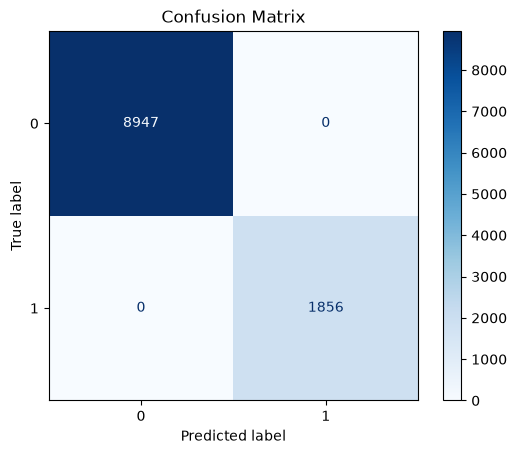

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas
rf_pd = rf_predictions.select("label", "prediction").toPandas()

# Create confusion matrix
cm = confusion_matrix(rf_pd["label"], rf_pd["prediction"])

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

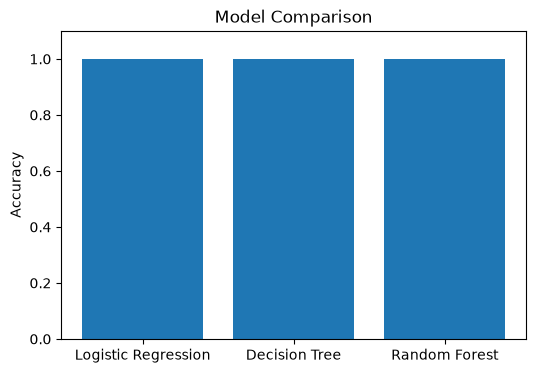

In [33]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [1.0, 1.0, 1.0]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

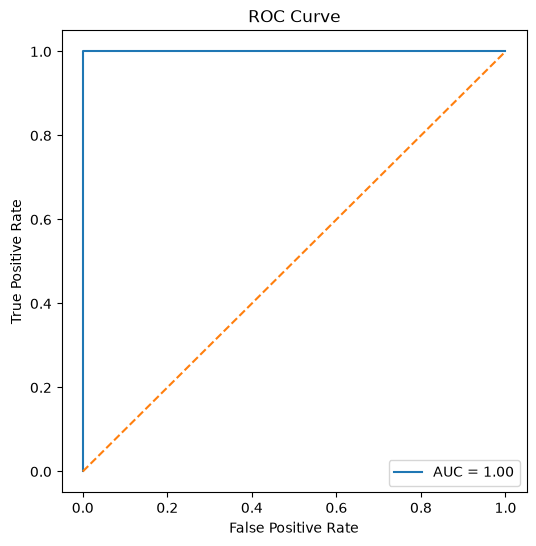

AUC: 1.0


In [34]:
from sklearn.metrics import roc_curve, auc

# Probability of positive class
y_true = rf_predictions.select("label").toPandas()["label"]
y_score = rf_predictions.select("probability").toPandas()["probability"].apply(lambda x: float(x[1]))

# ROC values
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC:", roc_auc)

In [35]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

metrics = {
    "Accuracy": "accuracy",
    "Precision": "weightedPrecision",
    "Recall": "weightedRecall",
    "F1 Score": "f1"
}

print("Random Forest Performance Metrics\n")

for metric_name, metric in metrics.items():
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    )

    score = evaluator.evaluate(rf_predictions)

    print(f"{metric_name}: {score:.4f}")

Random Forest Performance Metrics

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


                 Feature  Importance
0         departure_hour    0.999032
3          stop_sequence    0.000748
1             route_type    0.000139
4  wheelchair_accessible    0.000045
2           direction_id    0.000037


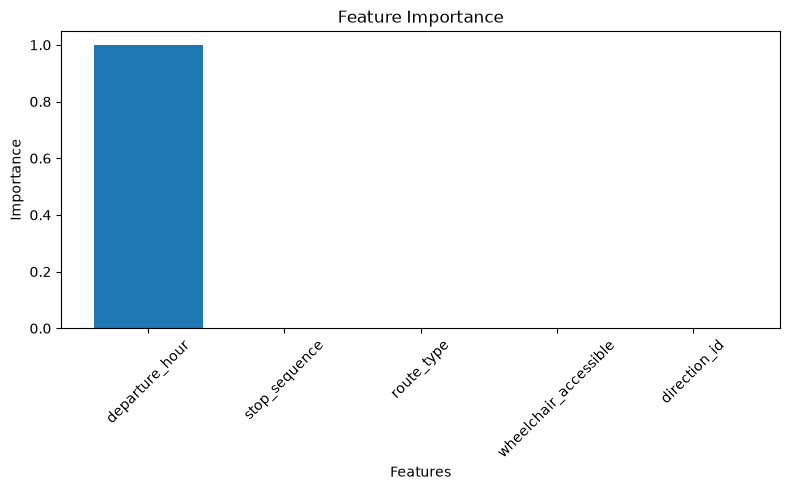

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.featureImportances.toArray()
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

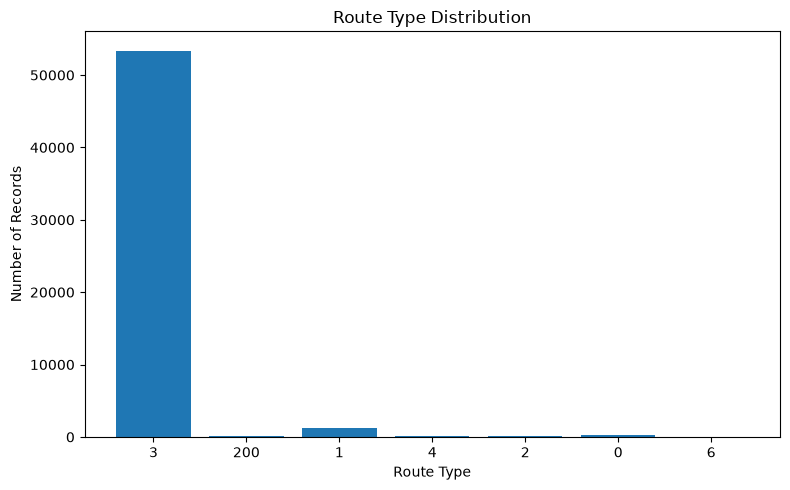

In [37]:
route_counts = bus_data.groupBy("route_type").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(
    route_counts["route_type"].astype(str),
    route_counts["count"]
)

plt.title("Route Type Distribution")
plt.xlabel("Route Type")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

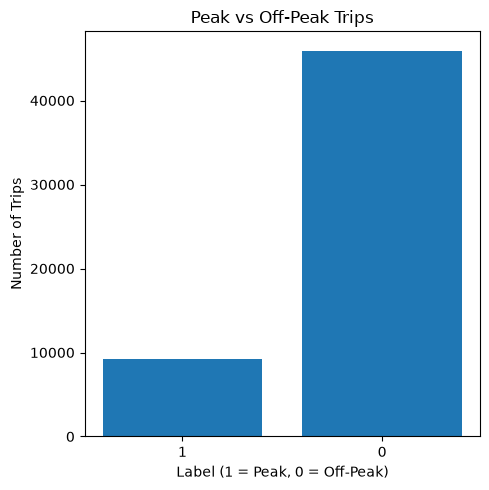

In [38]:
label_counts = bus_data.groupBy("label").count().toPandas()

plt.figure(figsize=(5,5))
plt.bar(
    label_counts["label"].astype(str),
    label_counts["count"]
)

plt.title("Peak vs Off-Peak Trips")
plt.xlabel("Label (1 = Peak, 0 = Off-Peak)")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

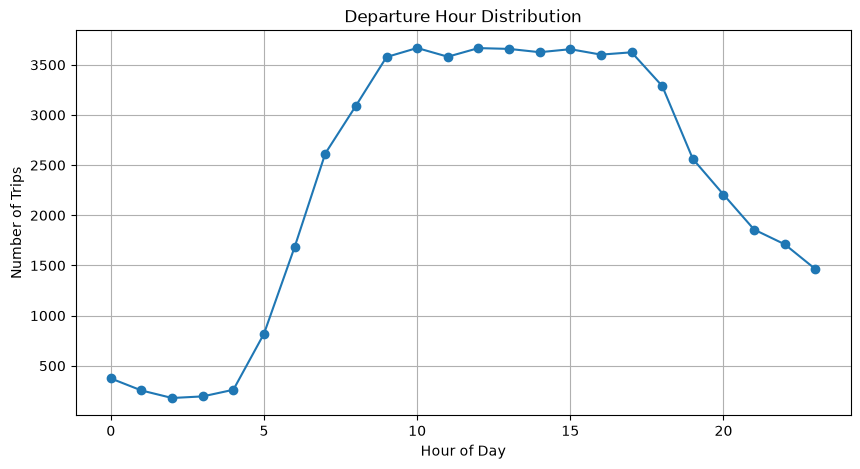

In [39]:
hour_counts = bus_data.groupBy("departure_hour").count().orderBy("departure_hour").toPandas()

plt.figure(figsize=(10,5))
plt.plot(hour_counts["departure_hour"], hour_counts["count"], marker="o")
plt.title("Departure Hour Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()

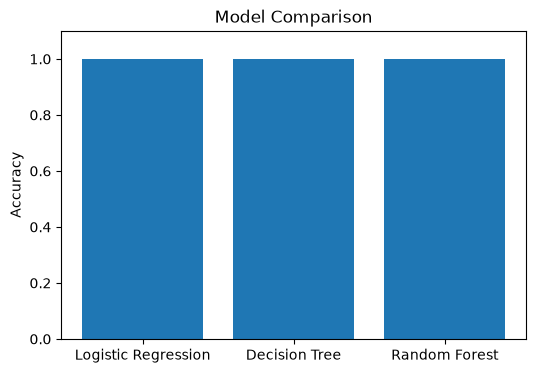

In [40]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [1.0, 1.0, 1.0]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()